# Credit Card Fraud Detection: Model Comparison

**Algorithms:** Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Support Vector Machine (SVM)

This notebook combines the four separate experiments into one reproducible workflow. It assumes the Kaggle-style `creditcard.csv` dataset is in the same folder. The target is `Class` (`1` = fraud, `0` = legitimate).

Because fraud is rare, the workflow uses a stratified train/test split and undersamples **only the training set**. The test set retains the original class distribution. Metrics emphasize fraud-class precision, recall, and F1 rather than accuracy alone.

## 1. Imports and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.utils import resample

In [2]:
RANDOM_STATE = 42
df = pd.read_csv("creditcard.csv")

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (53571, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [6]:
print("\nMissing values:", df.isna().sum().sum())


Missing values: 8


In [7]:
print("\nClass counts:")


Class counts:


In [11]:
df["Class"].value_counts().rename(index={0: "Legitimate", 1: "Fraud"})

,count
Class,
Legitimate,53417
Fraud,153


## 2. Exploratory data analysis

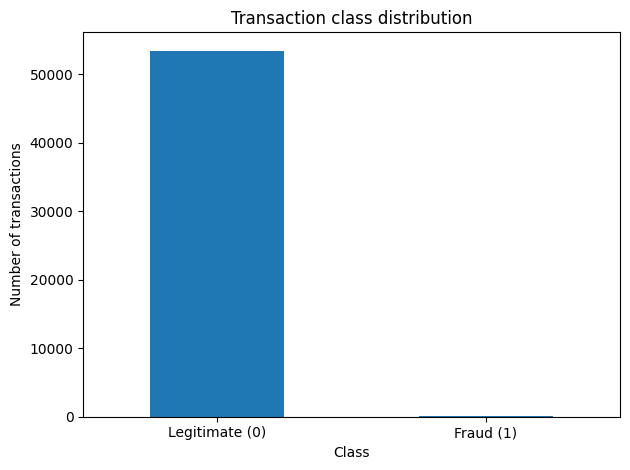

In [13]:
class_counts = df["Class"].value_counts().sort_index()
ax = class_counts.plot(kind="bar", rot=0, title="Transaction class distribution")
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
ax.set_ylabel("Number of transactions")
plt.tight_layout()
plt.show()

In [14]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,53417.0,94.251260,252.353693,0.0,7.68,25.52,86.65,12910.93
1.0,153.0,97.616013,230.026856,0.0,1.00,7.61,99.99,1809.68


## 3. Split data and address class imbalance

The split happens **before** undersampling to prevent information from the test set leaking into training. The training data is balanced by retaining all fraud examples and randomly sampling an equal number of legitimate examples. The test set remains untouched.

In [16]:
# Drop rows where the target 'Class' column is NaN
df = df.dropna(subset=["Class"])

# Verify that missing values in Class are gone
print("Missing values in Class:", df["Class"].isna().sum())

Missing values in Class: 0


In [17]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

In [18]:
train = X_train.copy()
train["Class"] = y_train
fraud_train = train[train["Class"] == 1]
legit_train = train[train["Class"] == 0].sample(
    n=len(fraud_train), random_state=RANDOM_STATE
)
train_balanced = pd.concat([legit_train, fraud_train]).sample(
    frac=1, random_state=RANDOM_STATE
)

In [19]:
X_train_bal = train_balanced.drop(columns="Class")
y_train_bal = train_balanced["Class"]

In [20]:
print("Original training counts:")
display(y_train.value_counts())
print("Balanced training counts:")
display(y_train_bal.value_counts())
print("Test counts (unchanged):")
display(y_test.value_counts())

Original training counts:


,count
Class,
0.0,42734
1.0,122


Balanced training counts:


,count
Class,
0.0,122
1.0,122


Test counts (unchanged):


,count
Class,
0.0,10683
1.0,31


## 4. Train four classifiers

In [21]:
# Scaling is included in pipelines for models sensitive to feature scale.
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy", random_state=RANDOM_STATE
    ),
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ])
}

In [22]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    fitted_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision (fraud)": precision_score(y_test, predictions, zero_division=0),
        "Recall (fraud)": recall_score(y_test, predictions, zero_division=0),
        "F1 (fraud)": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC (average precision)": average_precision_score(y_test, probabilities)
    })

In [23]:
results_df = pd.DataFrame(results).set_index("Model").sort_values(
    "F1 (fraud)", ascending=False
)
display(results_df.round(4))

,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC,PR-AUC (average precision)
Model,,,,,,
Logistic Regression,0.9912,0.2397,0.9355,0.3816,0.9957,0.6772
Support Vector Machine,0.9876,0.1812,0.9355,0.3037,0.9924,0.6624
K-Nearest Neighbors,0.9873,0.1739,0.9032,0.2917,0.9878,0.5113
Decision Tree,0.9467,0.0500,0.9677,0.0951,0.9572,0.0485


## 5. Compare model performance

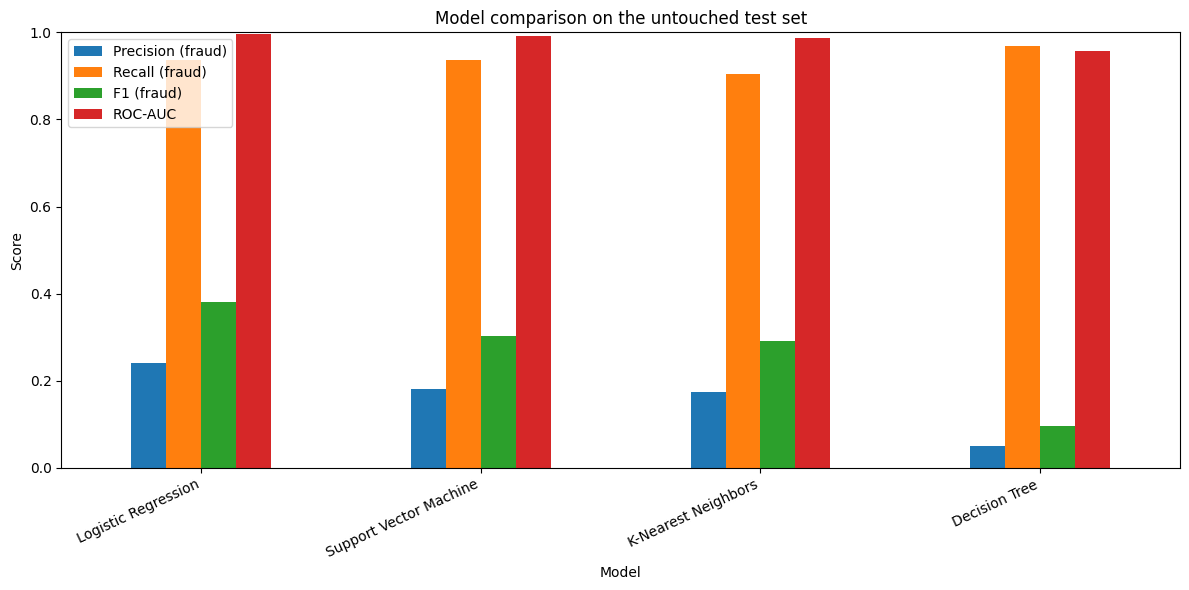

In [24]:
metrics_to_plot = ["Precision (fraud)", "Recall (fraud)", "F1 (fraud)", "ROC-AUC"]
results_df[metrics_to_plot].plot(kind="bar", figsize=(12, 6), ylim=(0, 1))
plt.title("Model comparison on the untouched test set")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 6. Confusion matrices and classification reports

--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     10683
       Fraud       0.24      0.94      0.38        31

    accuracy                           0.99     10714
   macro avg       0.62      0.96      0.69     10714
weighted avg       1.00      0.99      0.99     10714



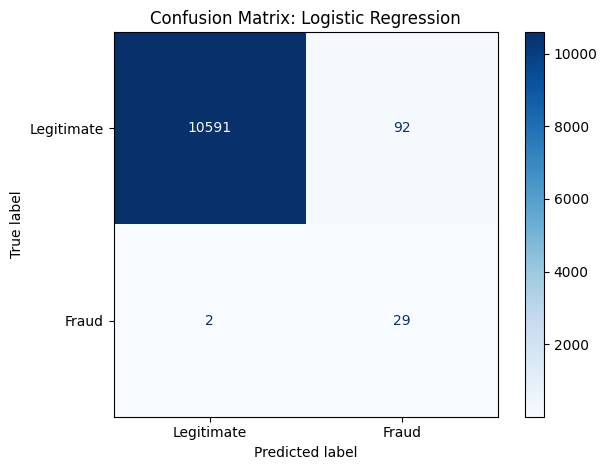

--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     10683
       Fraud       0.17      0.90      0.29        31

    accuracy                           0.99     10714
   macro avg       0.59      0.95      0.64     10714
weighted avg       1.00      0.99      0.99     10714



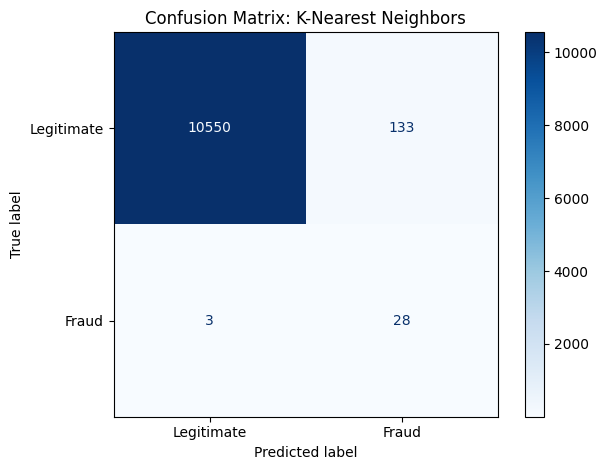

--- Decision Tree ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     10683
       Fraud       0.05      0.97      0.10        31

    accuracy                           0.95     10714
   macro avg       0.52      0.96      0.53     10714
weighted avg       1.00      0.95      0.97     10714



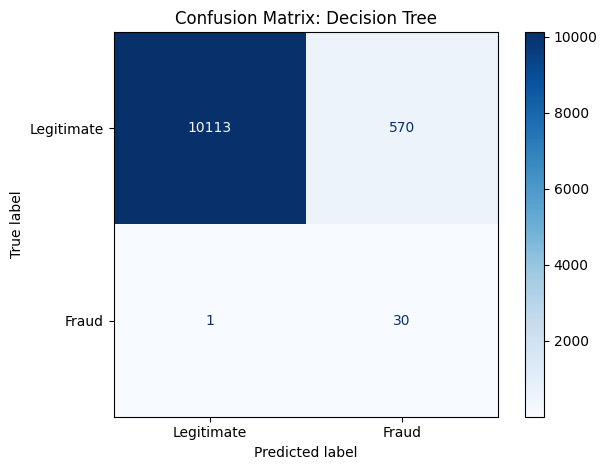

--- Support Vector Machine ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     10683
       Fraud       0.18      0.94      0.30        31

    accuracy                           0.99     10714
   macro avg       0.59      0.96      0.65     10714
weighted avg       1.00      0.99      0.99     10714



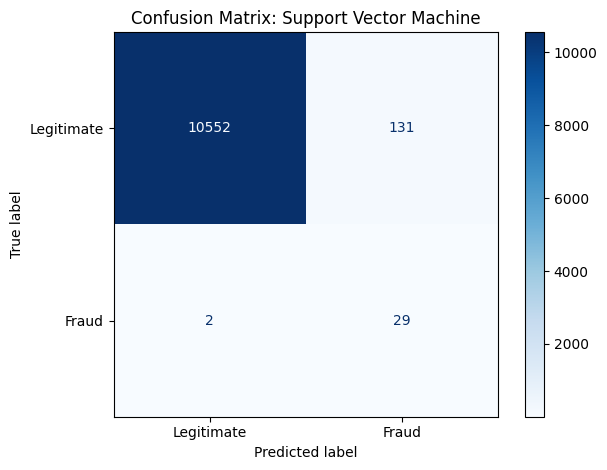

In [25]:
for name, model in fitted_models.items():
    predictions = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(
        y_test, predictions, target_names=["Legitimate", "Fraud"], zero_division=0
    ))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        display_labels=["Legitimate", "Fraud"],
        cmap="Blues", values_format="d"
    )
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

## 7. Conclusion

Use the comparison table to discuss the trade-offs between models. In fraud detection, **recall** describes how many actual fraud cases were detected, while **precision** describes how many flagged transactions were actually fraud. The appropriate operating point depends on the cost of missed fraud versus false alerts.

Record the measured test-set metrics from your run here before publishing. Results can vary with the dataset version and modeling choices. This notebook does not claim a particular model is best in advance.